In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# scikit learn train test split
from sklearn.model_selection import train_test_split

# for plotting
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sukhmandeepsinghbrar/housing-price-dataset")

print("Path to dataset files:", path)

100%|██████████| 780k/780k [00:00<00:00, 73.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sukhmandeepsinghbrar/housing-price-dataset/versions/1


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [ ]:
df = pd.read_csv('Housing.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# Counts the number of null values
na_values = df.isna().sum()

# Prints 0, meaning there are no null values
print(na_values)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


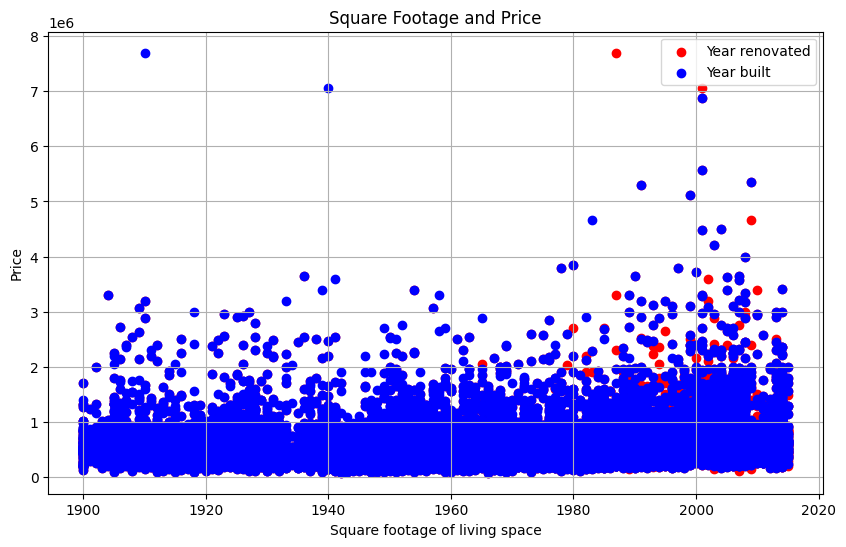

In [ ]:
# We tried to change this feature to account for all the 0's in year renovated, which would throw the model off
df.loc[df['yr_renovated'] == 0, "yr_renovated"] = df["yr_built"]

# However, from this plot we see that they almost completely overlap
plt.figure(figsize=(10, 6))
plt.scatter(df['yr_renovated'], df['price'], label = 'Year renovated', color = 'red')
plt.scatter(df['yr_built'], df['price'], label = 'Year built', color = 'blue')
plt.xlabel('Square footage of living space')
plt.ylabel('Price')
plt.title('Square Footage and Price')
plt.legend()
plt.grid(True)
plt.show()

# We can also see that neither of these features are correlated with a higher price

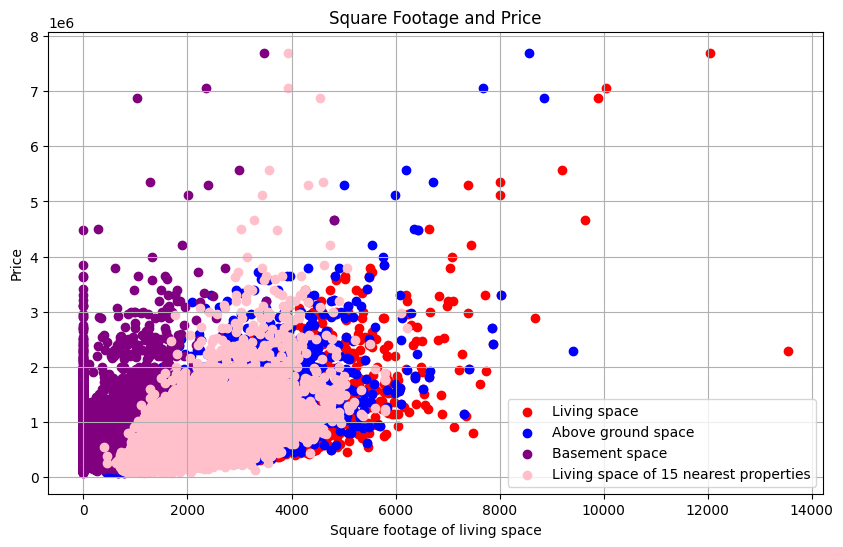

In [ ]:
# Plots various measures of square footage with price, showing us that basement space is not a reliable feature
plt.figure(figsize=(10, 6))
plt.scatter(df['sqft_living'], df['price'], label = "Living space", color = "red")
plt.scatter(df['sqft_above'], df['price'], label = "Above ground space", color = "blue")
plt.scatter(df['sqft_basement'], df['price'], label = "Basement space", color = "purple")
plt.scatter(df['sqft_living15'], df['price'], label = "Living space of 15 nearest properties", color = "pink")
plt.xlabel('Square footage of living space')
plt.ylabel('Price')
plt.title('Square Footage and Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# There is a huge outlier on the far right on the graph above for living space, and we are removing it here
df.drop(df['sqft_living'].idxmax())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,1955,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,1933,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,1965,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,1987,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,2009,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,2014,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,2009,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,2004,98027,47.5345,-122.069,1410,1287


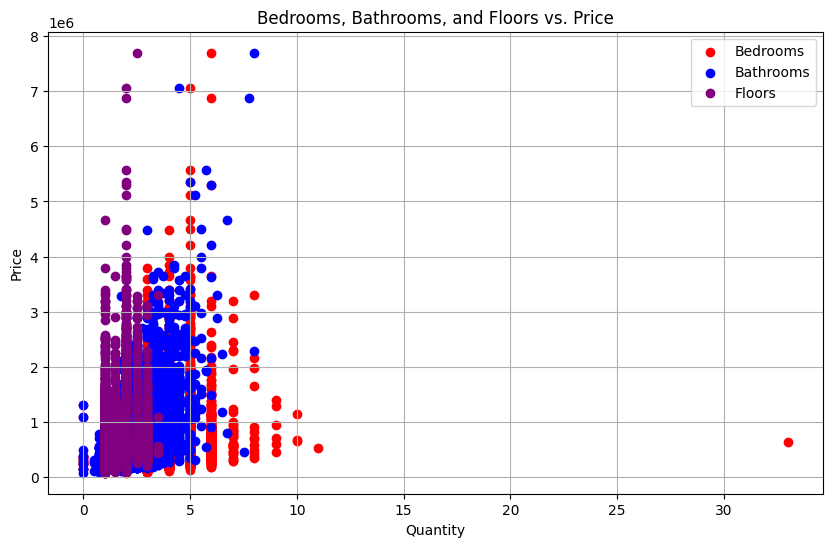

In [ ]:
# Plots bedrooms, bathrooms, and floors with price, showing us that none of these correlate strongly with a higher price
plt.figure(figsize=(10, 6))
plt.scatter(df['bedrooms'], df['price'], label = "Bedrooms", color = "red")
plt.scatter(df['bathrooms'], df['price'], label = "Bathrooms", color = "blue")
plt.scatter(df['floors'], df['price'], label = "Floors", color = "purple")
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.title('Bedrooms, Bathrooms, and Floors vs. Price')
plt.legend()
plt.grid(True)
plt.show()

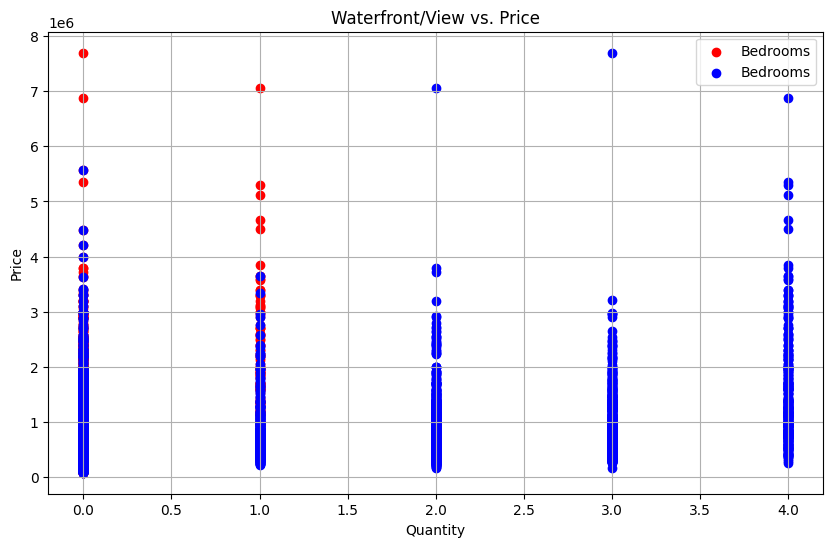

In [ ]:
# Plots waterfront and view with price, showing us that neither of these correlate strongly with a higher price
plt.figure(figsize=(10, 6))
plt.scatter(df['waterfront'], df['price'], label = "Bedrooms", color = "red")
plt.scatter(df['view'], df['price'], label = "Bedrooms", color = "blue")
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.title('Waterfront/View vs. Price')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-13-219759591.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


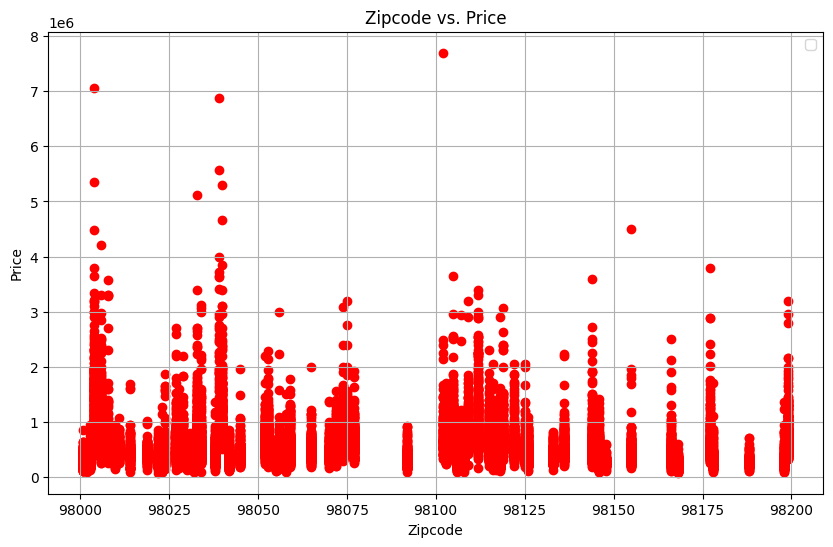

In [ ]:
# Plots zipcode with price, showing us that zipcode is not always reliable, but certain zipcodes show lower price
plt.figure(figsize=(10, 6))
plt.scatter(df['zipcode'], df['price'], color = "red")
plt.xlabel('Zipcode')
plt.ylabel('Price')
plt.title('Zipcode vs. Price')
plt.legend()
plt.grid(True)
plt.show()

# We noticed that some zipcodes relate to a higher price, but we were unfortunately unable to access each of the lower price zipcodes.
# The process was too tedious to execute, but here is one example below.

# tells us that one of the low zip codes is 98092
# print(h.loc[(h['zipcode'] > 98075) & (h['zipcode'] < 98100), 'zipcode'])

/tmp/ipython-input-14-2765169037.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


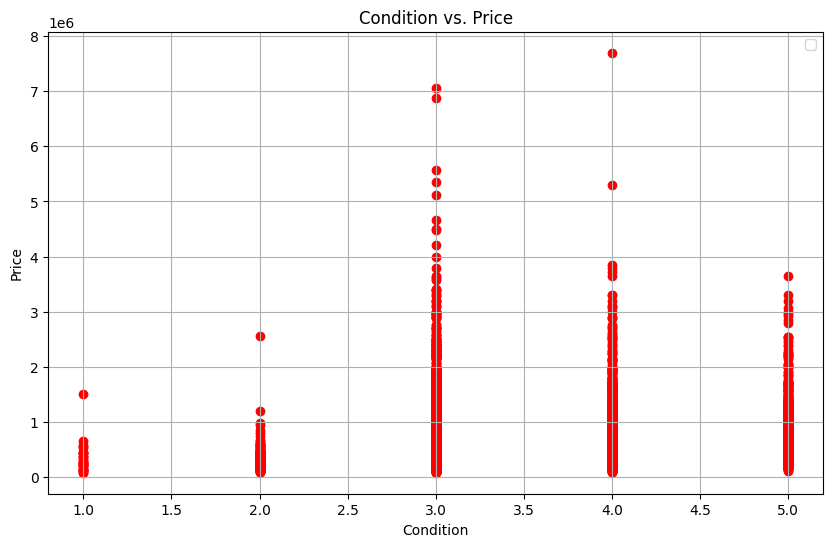

In [ ]:
# Plots condition with price, showing us that better condition is not always indicative of higher price, but lower condition is indicative of lower price
plt.figure(figsize=(10, 6))
plt.scatter(df['condition'], df['price'], color = "red")
plt.xlabel('Condition')
plt.ylabel('Price')
plt.title('Condition vs. Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Sets a new feature 'lower price' to 1 for poorer conditions and 0 for better conditions
df.loc[df['condition'] < 3, 'lower price'] = 1
df.loc[df['condition'] >= 3, 'lower price'] = 0

/tmp/ipython-input-16-3682250708.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


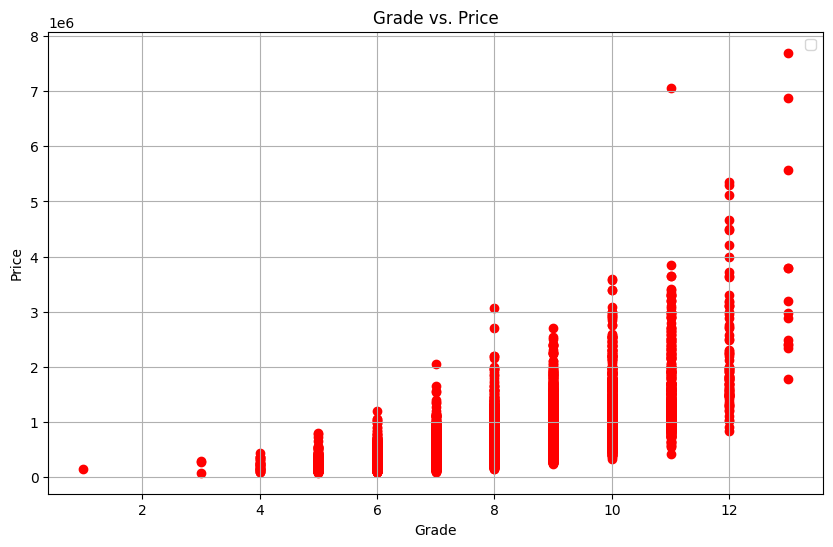

In [ ]:
# Plots grade with price, showing us that a higher grade is not always indicative of higher price, but lower grade is indicative of lower price
plt.figure(figsize=(10, 6))
plt.scatter(df['grade'], df['price'], color = "red")
plt.xlabel('Grade')
plt.ylabel('Price')
plt.title('Grade vs. Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Increments 'lower price' by 1 for lower grades
df.loc[df['grade'] < 7, 'lower price'] += 1

In [ ]:
# Removes columns that we have realized are less helpful in prediction
df = df.drop(columns=['id', 'date', 'lat', 'long', 'yr_renovated', 'bedrooms', 'bathrooms', 'floors', 'sqft_basement', 'waterfront', 'view', 'zipcode', 'condition', 'yr_built', 'grade'])
print(df)

          price  sqft_living  sqft_lot  sqft_above  sqft_living15  sqft_lot15  \
0      231300.0         1180      5650        1180           1340        5650   
1      538000.0         2570      7242        2170           1690        7639   
2      180000.0          770     10000         770           2720        8062   
3      604000.0         1960      5000        1050           1360        5000   
4      510000.0         1680      8080        1680           1800        7503   
...         ...          ...       ...         ...            ...         ...   
21608  360000.0         1530      1131        1530           1530        1509   
21609  400000.0         2310      5813        2310           1830        7200   
21610  402101.0         1020      1350        1020           1020        2007   
21611  400000.0         1600      2388        1600           1410        1287   
21612  325000.0         1020      1076        1020           1020        1357   

       lower price  
0     

In [ ]:
print(df)

# Loads dataframe to CSV to be used in Colab
df.to_csv('output2.csv', index=False)

          price  sqft_living  sqft_lot  sqft_above  sqft_living15  sqft_lot15  \
0      231300.0         1180      5650        1180           1340        5650   
1      538000.0         2570      7242        2170           1690        7639   
2      180000.0          770     10000         770           2720        8062   
3      604000.0         1960      5000        1050           1360        5000   
4      510000.0         1680      8080        1680           1800        7503   
...         ...          ...       ...         ...            ...         ...   
21608  360000.0         1530      1131        1530           1530        1509   
21609  400000.0         2310      5813        2310           1830        7200   
21610  402101.0         1020      1350        1020           1020        2007   
21611  400000.0         1600      2388        1600           1410        1287   
21612  325000.0         1020      1076        1020           1020        1357   

       lower price  
0     